<a href="https://colab.research.google.com/github/sikalova/cv_hw2/blob/main/hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers timm pycocotools tensorboard datasets

import os
import random
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import profile, record_function, ProfilerActivity
from transformers import DetrImageProcessor, DetrForObjectDetection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [3]:
!wget https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip
!unzip -q balloon_dataset.zip
class SimpleCOCODataset(torchvision.datasets.CocoDetection):
    def __init__(self, img_folder, ann_file, processor):
        super().__init__(img_folder, ann_file)
        self.processor = processor

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        image_id = self.ids[idx]
        boxes = []
        labels = []
        for ann in target:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])
        encoding = self.processor(images=img, annotations={'image_id': image_id, 'annotations': target}, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze()
        target_formatted = {
            'class_labels': torch.tensor(labels, dtype=torch.long),
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'orig_size': torch.tensor(img.size[::-1], dtype=torch.long)
        }
        w_img, h_img = img.size
        new_boxes = []
        for b in boxes:
            x_min, y_min, x_max, y_max = b
            c_x = (x_min + x_max) / 2 / w_img
            c_y = (y_min + y_max) / 2 / h_img
            w_obj = (x_max - x_min) / w_img
            h_obj = (y_max - y_min) / h_img
            new_boxes.append([c_x, c_y, w_obj, h_obj])
        target_formatted['boxes'] = torch.tensor(new_boxes, dtype=torch.float32)
        return pixel_values, target_formatted

CHECKPOINT = "facebook/detr-resnet-50"
processor = DetrImageProcessor.from_pretrained(CHECKPOINT)

from datasets import load_dataset
dataset_hf = load_dataset("cppe-5")

class HFToDetrDataset(torch.utils.data.Dataset):

    def __init__(self, hf_dataset, processor):
        self.dataset = hf_dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        image = item['image'].convert("RGB")
        objects = item['objects']
        labels = objects['category']
        boxes = objects['bbox']
        w_img, h_img = image.size
        norm_boxes = []
        for box in boxes:
            x, y, w, h = box
            cx = (x + w/2) / w_img
            cy = (y + h/2) / h_img
            nw = w / w_img
            nh = h / h_img
            norm_boxes.append([cx, cy, nw, nh])
        target = {
            'class_labels': torch.tensor(labels, dtype=torch.long),
            'boxes': torch.tensor(norm_boxes, dtype=torch.float32),
        }
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()
        return pixel_values, target

train_dataset = HFToDetrDataset(dataset_hf['train'], processor)
val_dataset = HFToDetrDataset(dataset_hf['test'], processor)
def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    encoding = processor.pad(pixel_values, return_tensors="pt")
    return encoding['pixel_values'], labels
train_loader = DataLoader(train_dataset, collate_fn=collate_fn, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, collate_fn=collate_fn, batch_size=2)
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

--2025-12-27 21:27:02--  https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/107595270/737339e2-2b83-11e8-856a-188034eb3468?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-27T22%3A25%3A05Z&rscd=attachment%3B+filename%3Dballoon_dataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-27T21%3A24%3A39Z&ske=2025-12-27T22%3A25%3A05Z&sks=b&skv=2018-11-09&sig=Jc5Anzr5aJEiKKcwgV5BA1P%2BIqadFg1AGKoONIDCctA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2Njg3MjYyMiwibmJmIjoxNzY2ODcwODIyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjd

In [4]:
id2label = {0: 'Coverall', 1: 'Face_Shield', 2: 'Gloves', 3: 'Mask', 4: 'Goggles'}
label2id = {v: k for k, v in id2label.items()}
num_labels = len(id2label)

model = DetrForObjectDetection.from_pretrained(
    CHECKPOINT,
    num_labels=num_labels,
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id
)
model.to(device)

optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if "backbone" not in n], 'lr': 1e-4},
    {'params': [p for n, p in model.named_parameters() if "backbone" in n], 'lr': 1e-5},
], weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

In [5]:
writer = SummaryWriter('runs/detr_experiment')
NUM_EPOCHS = 3
log_interval = 10
global_step = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for step, (pixel_values, labels) in enumerate(train_loader):
        pixel_values = pixel_values.to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in labels]
        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        if step % log_interval == 0:
            writer.add_scalar('Training/Total_Loss', loss.item(), global_step)
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{step}], Loss: {loss.item():.4f}")
        global_step += 1
    avg_loss = epoch_loss / len(train_loader)
    writer.add_scalar('Training/Epoch_Loss', avg_loss, epoch)
    lr_scheduler.step()
    torch.save(model.state_dict(), f"detr_checkpoint_epoch_{epoch}.pth")
writer.close()
print("Обучение завершено.")

Начинаем обучение...
Epoch [1/3], Step [0], Loss: 4.8231
Epoch [1/3], Step [10], Loss: 4.0368
Epoch [1/3], Step [20], Loss: 3.3789
Epoch [1/3], Step [30], Loss: 3.7553
Epoch [1/3], Step [40], Loss: 2.4413
Epoch [1/3], Step [50], Loss: 3.0953
Epoch [1/3], Step [60], Loss: 3.1313
Epoch [1/3], Step [70], Loss: 3.2612
Epoch [1/3], Step [80], Loss: 3.6307
Epoch [1/3], Step [90], Loss: 2.8361
Epoch [1/3], Step [100], Loss: 3.9593
Epoch [1/3], Step [110], Loss: 3.6445
Epoch [1/3], Step [120], Loss: 3.6649
Epoch [1/3], Step [130], Loss: 2.4832
Epoch [1/3], Step [140], Loss: 4.1356
Epoch [1/3], Step [150], Loss: 3.2137
Epoch [1/3], Step [160], Loss: 3.9417
Epoch [1/3], Step [170], Loss: 2.9675
Epoch [1/3], Step [180], Loss: 3.4676
Epoch [1/3], Step [190], Loss: 4.5367
Epoch [1/3], Step [200], Loss: 3.5982
Epoch [1/3], Step [210], Loss: 2.3054
Epoch [1/3], Step [220], Loss: 3.9179
Epoch [1/3], Step [230], Loss: 4.0384
Epoch [1/3], Step [240], Loss: 2.3551
Epoch [2/3], Step [0], Loss: 3.0146
Epoc

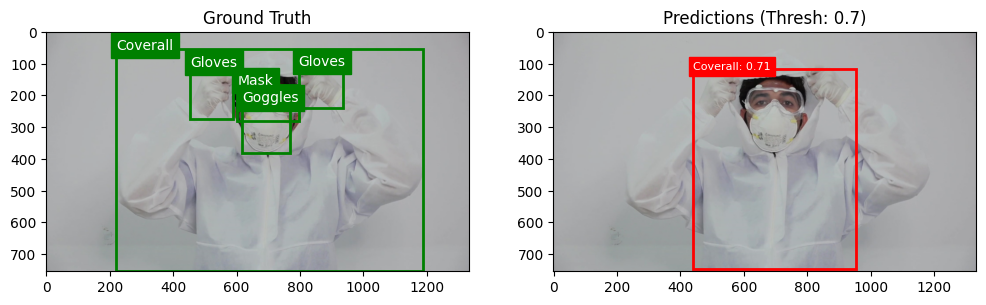

--- Error Analysis Report ---
Ground Truth objects: 5
Predicted objects: 1
Note: If huge box mismatch -> Localization Error.
Note: If boxes match but label wrong -> Classification Error.


In [6]:
def analyze_predictions(model, dataset, index=0, threshold=0.7):
    model.eval()
    pixel_values, target = dataset[index]
    with torch.no_grad():
        outputs = model(pixel_values.unsqueeze(0).to(device))
    orig_target_sizes = torch.tensor([[800, 800]])
    results = processor.post_process_object_detection(outputs, target_sizes=orig_target_sizes, threshold=threshold)[0]
    img_tensor = pixel_values.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_tensor = std * img_tensor + mean
    img_tensor = np.clip(img_tensor, 0, 1)
    plt.figure(figsize=(12, 6))
    h, w, _ = img_tensor.shape
    gt_boxes = target['boxes'].cpu().numpy()
    gt_labels = target['class_labels'].cpu().numpy()
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(img_tensor)
    ax1.set_title("Ground Truth")
    for box, lbl in zip(gt_boxes, gt_labels):
        cx, cy, bw, bh = box
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        rect = plt.Rectangle((x1, y1), bw*w, bh*h, fill=False, color='green', linewidth=2)
        ax1.add_patch(rect)
        ax1.text(x1, y1, f"{id2label.get(int(lbl), lbl)}", color='white', backgroundcolor='green')
    pred_boxes = results['boxes'].cpu().numpy()
    pred_scores = results['scores'].cpu().numpy()
    pred_labels = results['labels'].cpu().numpy()
    scale_x = w / 800
    scale_y = h / 800
    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(img_tensor)
    ax2.set_title(f"Predictions (Thresh: {threshold})")
    for box, score, lbl in zip(pred_boxes, pred_scores, pred_labels):
        x1, y1, x2, y2 = box
        x1, x2 = x1*scale_x, x2*scale_x
        y1, y2 = y1*scale_y, y2*scale_y
        color = 'red' if score < 0.8 else 'blue'
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color=color, linewidth=2)
        ax2.add_patch(rect)
        ax2.text(x1, y1, f"{id2label.get(int(lbl), lbl)}: {score:.2f}", color='white', backgroundcolor=color, fontsize=8)
    plt.show()

    print("--- Error Analysis Report ---")
    print(f"Ground Truth objects: {len(gt_boxes)}")
    print(f"Predicted objects: {len(pred_boxes)}")
    if len(gt_boxes) > 0 and len(pred_boxes) > 0:
        print("Note: If huge box mismatch -> Localization Error.")
        print("Note: If boxes match but label wrong -> Classification Error.")
    else:
        print("Missed detection or Hallucination.")
analyze_predictions(model, val_dataset, index=0)


In [8]:
!zip -r tensorboard_logs.zip runs/

from google.colab import files
files.download('tensorboard_logs.zip')
files.download(f"detr_checkpoint_epoch_{NUM_EPOCHS-1}.pth")

  adding: runs/ (stored 0%)
  adding: runs/detr_experiment/ (stored 0%)
  adding: runs/detr_experiment/events.out.tfevents.1766870993.2f3c962437b4.834.0 (deflated 66%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>